In [122]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim

In [123]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [124]:
df = df.drop('customerID', axis=1)

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [126]:
df['TotalCharges'].dtype

dtype('O')

In [127]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(df['TotalCharges'].isnull().sum())

0


In [128]:
Num_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
print(f'Numerical columns: {Num_cols}')

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [129]:
for col in df.columns:
    if col not in Num_cols:
        print(f"{col}: {df[col].unique()} ")
        print('___')

gender: ['Female' 'Male'] 
___
Partner: ['Yes' 'No'] 
___
Dependents: ['No' 'Yes'] 
___
PhoneService: ['No' 'Yes'] 
___
MultipleLines: ['No phone service' 'No' 'Yes'] 
___
InternetService: ['DSL' 'Fiber optic' 'No'] 
___
OnlineSecurity: ['No' 'Yes' 'No internet service'] 
___
OnlineBackup: ['Yes' 'No' 'No internet service'] 
___
DeviceProtection: ['No' 'Yes' 'No internet service'] 
___
TechSupport: ['No' 'Yes' 'No internet service'] 
___
StreamingTV: ['No' 'Yes' 'No internet service'] 
___
StreamingMovies: ['No' 'Yes' 'No internet service'] 
___
Contract: ['Month-to-month' 'One year' 'Two year'] 
___
PaperlessBilling: ['Yes' 'No'] 
___
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] 
___
Churn: ['No' 'Yes'] 
___


In [130]:
def replacing(df, column):
    for col in column:
        df[col] = df[col].replace('No internet service', 'No')
    return df
replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df = replacing(df, replace_cols)

In [131]:
def map_zero_one(df, column):
    for col in column:
        df[col] = df[col].map({'Yes': 1, 'No': 0})
    return df
mapping = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df = map_zero_one(df, mapping)

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [132]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [134]:
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
print(f'Categorical columns: {categorical_cols}')

Categorical columns: ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']


In [135]:
for col in df.columns:
    if col in categorical_cols:
        print(f"{col}: {df[col].unique()} ")
        print('___')

MultipleLines: ['No phone service' 'No' 'Yes'] 
___
InternetService: ['DSL' 'Fiber optic' 'No'] 
___
Contract: ['Month-to-month' 'One year' 'Two year'] 
___
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] 
___


In [ ]:
encoder = OneHotEncoder(sparse=False, drop='first')
encoded_cols = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(categorical_cols))
df = pd.concat([df.drop(categorical_cols, axis=1), encoded_df], axis=1)
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,0,0,...,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,1,0,1,0,...,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [137]:
scalar = StandardScaler()
scailing_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[scailing_cols] = scalar.fit_transform(df[scailing_cols])

In [138]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [139]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [140]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 24), (1409, 24), (5634,), (1409,))

In [141]:
# Converting to pytorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [142]:
class ChurnDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [143]:
train_dataset = ChurnDataset(X_train_tensor, y_train_tensor)
test_dataset = ChurnDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [144]:
# Defining the ANN model
class ChurnModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.container = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.container(x)    

In [145]:
model = ChurnModel(X_train_tensor.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
num_epochs = 50

In [146]:
patience = 7
best_val_loss = float('inf')
counter = 0

for epoch in range(num_epochs):

    # -------- TRAIN --------
    model.train()
    total_loss = 0

    for batch_features, batch_labels in train_loader:
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_loss_total = 0

    with torch.no_grad():
        for val_features, val_labels in test_loader:
            val_outputs = model(val_features)
            val_loss = criterion(val_outputs, val_labels)
            val_loss_total += val_loss.item()

    avg_val_loss = val_loss_total / len(test_loader)

    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # -------- EARLY STOPPING --------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        print(f"Early stopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered!")
            break

Epoch 1, Train Loss: 0.4763, Val Loss: 0.4178
Epoch 2, Train Loss: 0.4321, Val Loss: 0.4134
Epoch 3, Train Loss: 0.4260, Val Loss: 0.4061
Epoch 4, Train Loss: 0.4250, Val Loss: 0.4077
Early stopping counter: 1/7
Epoch 5, Train Loss: 0.4236, Val Loss: 0.4070
Early stopping counter: 2/7
Epoch 6, Train Loss: 0.4231, Val Loss: 0.4105
Early stopping counter: 3/7
Epoch 7, Train Loss: 0.4193, Val Loss: 0.4077
Early stopping counter: 4/7
Epoch 8, Train Loss: 0.4156, Val Loss: 0.4047
Epoch 9, Train Loss: 0.4143, Val Loss: 0.4061
Early stopping counter: 1/7
Epoch 10, Train Loss: 0.4157, Val Loss: 0.4078
Early stopping counter: 2/7
Epoch 11, Train Loss: 0.4163, Val Loss: 0.4083
Early stopping counter: 3/7
Epoch 12, Train Loss: 0.4107, Val Loss: 0.4077
Early stopping counter: 4/7
Epoch 13, Train Loss: 0.4129, Val Loss: 0.4076
Early stopping counter: 5/7
Epoch 14, Train Loss: 0.4093, Val Loss: 0.4044
Epoch 15, Train Loss: 0.4054, Val Loss: 0.4032
Epoch 16, Train Loss: 0.4054, Val Loss: 0.4071
Early

In [147]:
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.4).float()
    
accuracy = (preds == y_test_tensor).sum() / len(y_test_tensor)
print(f'Test Accuracy: {accuracy:.4f}')

Test Accuracy: 0.8041


In [148]:
# Train Accuracy
model.eval()
with torch.no_grad():
    outputs = model(X_train_tensor)
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.4).float()
    
accuracy = (preds == y_train_tensor).sum() / len(y_train_tensor)
print(f'Train Accuracy: {accuracy:.4f}')

Train Accuracy: 0.8170


In [149]:
from sklearn.metrics import f1_score, precision_score, recall_score

preds = (torch.sigmoid(model(X_test_tensor)) > 0.4).float()
f1 = f1_score(y_test_tensor, preds)
precision = precision_score(y_test_tensor, preds)
recall = recall_score(y_test_tensor, preds)

print(f'F1 Score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')

F1 Score: 0.6240, Precision: 0.6343, Recall: 0.6139


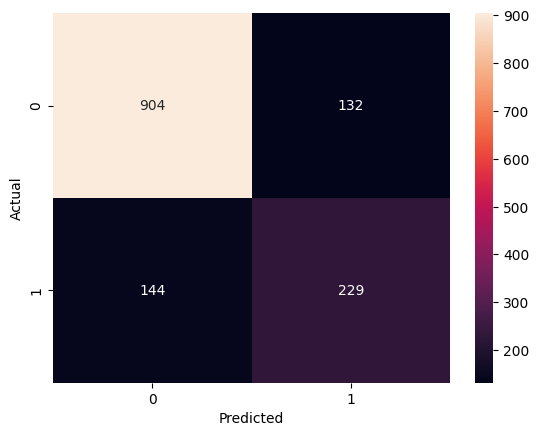

In [150]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_tensor, preds)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [151]:
new_customer = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'No',
    'PaperlessBilling': 'Yes',
    'MonthlyCharges': 75.0,
    'TotalCharges': 900.0,
    'MultipleLines': 'No phone service',
    'InternetService': 'Fiber optic',
    'Contract': 'Month-to-month',
    'PaymentMethod': 'Electronic check'
}
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Convert to DataFrame
df_new = pd.DataFrame([new_customer])

# Encode binary Yes/No columns
yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in yes_no_cols:
    df_new[col] = df_new[col].map({'Yes':1, 'No':0})

# Encode gender
df_new['gender'] = df_new['gender'].map({'Male':1, 'Female':0})

# Replace 'No internet service' if needed
replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in replace_cols:
    df_new[col] = df_new[col].replace('No internet service', 0)

# One-hot encoding for categorical columns
categorical_cols = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']
df_new = pd.get_dummies(df_new, columns=categorical_cols, drop_first=True)

# Ensure same columns as training data
for col in df.columns.drop('Churn'):
    if col not in df_new.columns:
        df_new[col] = 0

# Reorder columns to match training set
df_new = df_new[df.columns.drop('Churn')]

# Scale numeric columns
scaler = StandardScaler()
scaling_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_new[scaling_cols] = scaler.fit_transform(df_new[scaling_cols])
import torch

X_new_tensor = torch.tensor(df_new.values, dtype=torch.float32)
with torch.no_grad():
    output = model(X_new_tensor)
    prob = torch.sigmoid(output)        # convert logits to probability
    prediction = (prob > 0.5).float()   # threshold 0.5

print(f"Predicted Probability of Churn: {prob.item():.4f}")
if prediction.item() == 1:
    print("The customer is likely to CHURN.")
else:
    print("The customer is likely to STAY.")

Predicted Probability of Churn: 0.1780
The customer is likely to STAY.
